In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [118]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\aris\Export.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6143 entries, 0 to 6142
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  6143 non-null   str  
 1   Message  6143 non-null   str  
 2   Status   6143 non-null   str  
dtypes: str(3)
memory usage: 144.1 KB


In [119]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252513    5692
0x252514     429
0x252501      11
0x252511      11
Name: count, dtype: int64

In [120]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6143 entries, 0 to 6142
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  6143 non-null   str  
 1   Message  6143 non-null   str  
 2   Status   6143 non-null   str  
 3   Headers  6143 non-null   str  
dtypes: str(4)
memory usage: 192.1 KB


Odometer

In [121]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 6121 entries, 0 to 6142
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             6121 non-null   str  
 1   Message             6121 non-null   str  
 2   Status              6121 non-null   str  
 3   Headers             6121 non-null   str  
 4   Odometer in meters  6121 non-null   int64
 5   Date                6121 non-null   str  
 6   Raw data            6121 non-null   str  
dtypes: int64(1), str(6)
memory usage: 382.6 KB
None


260901134111 -> 0 -> 13417494.0 -> 0x252514005919380869487064556540001EFFFF2D000022E44E00000007000061000000FFFFFFFFFFFFFFFFFFFF16D500CCBC160026090113411166467C44F30D99C26FD65C400000014B03921284FFFFFF0000210000FFFFFF
260901134142 -> 1 -> 13417494.0 -> 0x25251300598FE80869487064556540001EFFFF2D000022E44F00000007000061000000FFFFFFFFFFFFFFFFFFFF00D500CCBC160026090113414266467C44F30D99C26FD65C400000014B03921255FFFFFF0000210000FFFFFF
260901134212 -> 2 -> 13417494.0 -> 0x25251300598FE90869487064556540001EFFFF2D000022E44F00000007000061000000FFFFFFFFFFFFFFFFFFFF00D500CCBC160026090113421266467C44F30D99C26FD65C400000014B03921254FFFFFF0000210000FFFFFF
260901134242 -> 3 -> 13417494.0 -> 0x25251300598FEA0869487064556540001EFFFF2D000022E44F00000007000061000000FFFFFFFFFFFFFFFFFFFF00D500CCBC160026090113424266467C44F30D99C26FD65C400000014B03921253FFFFFF0000210000FFFFFF
260901134312 -> 4 -> 13417494.0 -> 0x25251300598FEB0869487064556540001EFFFF2D000022E44D00000007000061000000FFFFFFFFFFFFFFFFFFFF00D500CCB

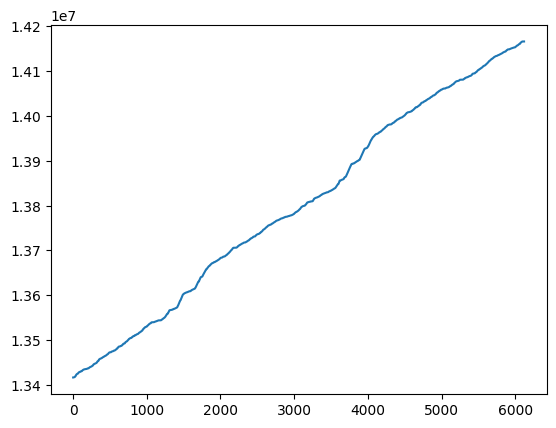

In [122]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [123]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            #print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 6118 entries, 5690 to 6117
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     6118 non-null   int64
 1   Date      6118 non-null   str  
 2   Raw data  6118 non-null   str  
dtypes: int64(1), str(2)
memory usage: 191.2 KB
None


260901144928 -> 125 -> 62.0 -> 0x2525130059905E0869487064556540001EFFFF2D000022E45200000007000061000000FFFFFFFFFFFFFFFFFFFF00D500CCF85D002609011449289A397844651299C25A325C400620003803921455FFFFFF00002C0000FFFFFF
260901174739 -> 325 -> 56.0 -> 0x2525130059911B0869487064556540001EFFFF2D000022E45000000007000061000000FFFFFFFFFFFFFFFFFFFF00D500CD42160026090117473966E67044A5F798C2799B5B400560000003931461FFFFFF0000310000FFFFFF
260901180039 -> 343 -> 62.0 -> 0x2525130059912B0869487064556540001EFFFF2D000022E05100000007000061000000FFFFFFFFFFFFFFFFFFFF00D500CD4CEF00260901180039664671442AFD98C2BA565C40062000F903921469FFFFFF0000310000FFFFFF
260901180211 -> 346 -> 57.0 -> 0x2525130059912E0869487064556540001EFFFF2D000022E45000000007000061000000FFFFFFFFFFFFFFFFFFFF00D500CD52430026090118021133137344170399C26D145C40057000F903931464FFFFFF0000310000FFFFFF
260903154405 -> 1442 -> 57.0 -> 0x252513005995170869487064556540001EFFFF2D000022C15100000007000061000000FFFFFFFFFFFFFFFFFFFF00D500CF4A3A002609031544059A

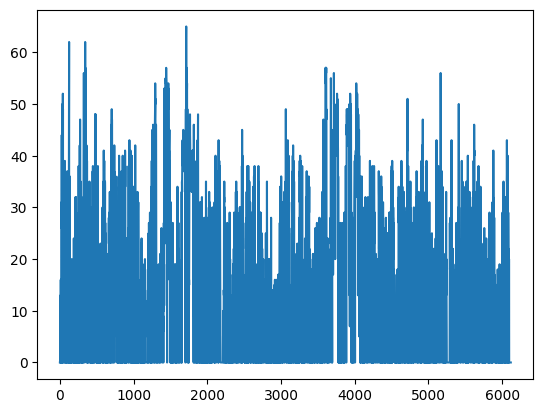

In [124]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])
    #print(raw_data_[i])

for i in range(0,len(speed)):
    if (y_axis[i]>55):
        print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

plt.plot(x_axis,y_axis)

In [125]:
print("Max speed: ",max(y_axis))

Max speed:  65.0


Satellites

In [126]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)
unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<1:
        num_events=num_events+1
        print(unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,5],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 6121 entries, 0 to 6142
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         6121 non-null   str  
 1   Message                         6121 non-null   str  
 2   Status                          6121 non-null   str  
 3   Headers                         6121 non-null   str  
 4   Satellites                      6121 non-null   int64
 5   Satellite_connection_indicator  6121 non-null   int64
 6   Raw data                        6121 non-null   str  
 7   date                            6121 non-null   str  
dtypes: int64(2), str(6)
memory usage: 430.4 KB
2026-09-05 15:17:55.579 -> 0 -> 0 -> 0x25251300599A1F0869487064556540001EFFFF2D000022E00000000007000061000000FFFFFFFFFFFFFFFFFFFF00D500D220F20026090515180982DC0065001D0697698101960196018203921466FFFFFF00002E0000FFFFFF
2026-09-08 22:53:29.437 -> 0 -> 0 -> 0x25251300599F800

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [127]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16)))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

#in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 6121 entries, 1 to 6142
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  6121 non-null   str  
 1   Message  6121 non-null   str  
 2   Status   6121 non-null   str  
 3   Headers  6121 non-null   str  
dtypes: str(4)
memory usage: 239.1 KB


Ignition

In [128]:
in_outs_df.info()

for i in range(0,in_outs_df.shape[0]):
    length=len(in_outs_df.iloc[i,0])
    if length>16:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])
    else:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])

<class 'pandas.DataFrame'>
Index: 6121 entries, 5692 to 6120
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  6121 non-null   str  
 1   date         6121 non-null   str  
 2   raw data     6121 non-null   str  
dtypes: str(3)
memory usage: 191.3 KB
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition On 0b110000100000000
Ignition 

Power

In [129]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 6121 entries, 1 to 6142
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  6121 non-null   str  
 1   Message  6121 non-null   str  
 2   Status   6121 non-null   str  
 3   Headers  6121 non-null   str  
dtypes: str(4)
memory usage: 239.1 KB
Empty DataFrame
Columns: []
Index: []


Pánico

In [130]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
Index: 6121 entries, 1 to 6142
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  6121 non-null   str  
 1   Message  6121 non-null   str  
 2   Status   6121 non-null   str  
 3   Headers  6121 non-null   str  
dtypes: str(4)
memory usage: 239.1 KB
len aux_cad:  6121


Speed report

In [131]:
speed_report=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\aris\speedReport_2026-09-14_1789396915161_ptjzd2i8s.csv',sep=',')
speed_report.info()

<class 'pandas.DataFrame'>
RangeIndex: 99747 entries, 0 to 99746
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unit               99747 non-null  str  
 1   Driver             45246 non-null  str  
 2   Time/Date (UTC-5)  99747 non-null  str  
 3   Address            99747 non-null  str  
 4   Speed (kph)        99747 non-null  int64
 5   Posted Speed       99747 non-null  str  
 6   Signal             99747 non-null  int64
dtypes: int64(2), str(5)
memory usage: 5.3 MB


In [132]:
speed_report['Speed (kph)'].describe()

count    99747.000000
mean        21.576358
std         14.458029
min          2.000000
25%         11.000000
50%         18.000000
75%         29.000000
max         98.000000
Name: Speed (kph), dtype: float64

In [135]:
for i in range(0,speed_report.shape[0]):
    if speed_report.iloc[i,4]>49:
        if speed_report.iloc[i,0]=='650AFY':
            print(speed_report.iloc[i,0],'->',speed_report.iloc[i,4],'->',speed_report.iloc[i,5],speed_report.iloc[i,2])

650AFY -> 50 -> 80 01/09/2026 8:57 AM
650AFY -> 50 -> 80 01/09/2026 8:57 AM
650AFY -> 50 -> 60 01/09/2026 8:58 AM
650AFY -> 50 -> 60 01/09/2026 8:58 AM
650AFY -> 52 -> 80 01/09/2026 8:59 AM
650AFY -> 52 -> 80 01/09/2026 8:59 AM
650AFY -> 63 -> 80 01/09/2026 9:49 AM
650AFY -> 63 -> 80 01/09/2026 9:49 AM
650AFY -> 52 -> 80 01/09/2026 12:47 PM
650AFY -> 52 -> 80 01/09/2026 12:47 PM
650AFY -> 56 -> 80 01/09/2026 12:47 PM
650AFY -> 56 -> 80 01/09/2026 12:47 PM
650AFY -> 63 -> 80 01/09/2026 1:00 PM
650AFY -> 63 -> 80 01/09/2026 1:00 PM
650AFY -> 52 -> 80 01/09/2026 1:01 PM
650AFY -> 52 -> 80 01/09/2026 1:01 PM
650AFY -> 56 -> 80 01/09/2026 1:02 PM
650AFY -> 56 -> 80 01/09/2026 1:02 PM
650AFY -> 50 -> 100 03/09/2026 9:22 AM
650AFY -> 50 -> 100 03/09/2026 9:22 AM
650AFY -> 55 -> 100 03/09/2026 9:22 AM
650AFY -> 55 -> 100 03/09/2026 9:22 AM
650AFY -> 52 -> 100 03/09/2026 9:23 AM
650AFY -> 52 -> 100 03/09/2026 9:23 AM
650AFY -> 50 -> 40 03/09/2026 9:23 AM
650AFY -> 50 -> 40 03/09/2026 9:23 AM
65

In [134]:
for i in range(0,speed_report.shape[0]):
    try:
        if (speed_report.iloc[i,4]>int(speed_report.iloc[i,5])):
            print(speed_report.iloc[i,0],'->',speed_report.iloc[i,4],'->',speed_report.iloc[i,5],speed_report.iloc[i,2])
    except:
        pass



650AFY -> 43 -> 40 01/09/2026 8:51 AM
650AFY -> 43 -> 40 01/09/2026 8:51 AM
650AFY -> 43 -> 40 01/09/2026 9:49 AM
650AFY -> 43 -> 40 01/09/2026 9:49 AM
650AFY -> 42 -> 40 01/09/2026 1:06 PM
650AFY -> 42 -> 40 01/09/2026 1:06 PM
650AFY -> 47 -> 40 01/09/2026 3:53 PM
650AFY -> 47 -> 40 01/09/2026 3:53 PM
650AFY -> 48 -> 40 01/09/2026 3:54 PM
650AFY -> 48 -> 40 01/09/2026 3:54 PM
650AFY -> 50 -> 40 03/09/2026 9:23 AM
650AFY -> 50 -> 40 03/09/2026 9:23 AM
650AFY -> 47 -> 40 08/09/2026 2:49 PM
650AFY -> 47 -> 40 08/09/2026 2:49 PM
650AFY -> 14 -> 10 08/09/2026 5:24 PM
650AFY -> 14 -> 10 08/09/2026 5:24 PM
650AFY -> 52 -> 40 09/09/2026 2:20 PM
650AFY -> 52 -> 40 09/09/2026 2:20 PM
650AFY -> 43 -> 40 10/09/2026 10:51 AM
650AFY -> 43 -> 40 10/09/2026 10:51 AM
719AHB -> 58 -> 40 01/09/2026 11:11 AM
719AHB -> 58 -> 40 01/09/2026 11:11 AM
719AHB -> 43 -> 40 02/09/2026 12:34 PM
719AHB -> 43 -> 40 02/09/2026 12:34 PM
719AHB -> 48 -> 40 02/09/2026 12:50 PM
719AHB -> 48 -> 40 02/09/2026 12:50 PM
719A